# Backtesting an ML strategy with Backtrader

**Eight notebooks** cover the workflow sequence:
1. [create_datasets_yf.ipynb](01_create_datasets_yf.ipynb) : creates datasets using yfinance
2. [sentiment_feature_building](02_sentiment_feature_building.ipynb): (optional) we calculate the sentiment using finbert on financial news
3. [feature_engineering_yf](03_feature_engineering_yf.ipynb): we compute features from data to later feed into the model
4. [optimizing_xgboost](04_optimizing_xgboost.ipynb): we train a xgboost model to predict returns
5. [evaluate_xgboost](05_evaluate_xgboost.ipynb): we compare the cross-validation performance using various metrics to select the best model. 
6. [model_interpretation](06_model_interpretation.ipynb): we take a closer look at the drivers behind the best model's predictions.
7. [making_out_of_sample_predictions](07_making_out_of_sample_predictions.ipynb): we predict returns for our out-of-sample period
8. `backtest_backtrader`(this notebook): evaluate the historical performance of our strategy based on our predictive signals

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline

from pathlib import Path
import csv
from time import time
import datetime
from datetime import datetime
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns

import backtrader as bt
from backtrader.feeds import PandasData

import quantstats as qs
import yfinance as yf


#import pyfolio as pf

In [3]:
pd.set_option('display.expand_frame_repr', False)
np.random.seed(42)
sns.set_style('darkgrid')
idx = pd.IndexSlice

In [4]:
def format_time(t):
    m_, s = divmod(t, 60)
    h, m = divmod(m_, 60)
    return f'{h:>02.0f}:{m:>02.0f}:{s:>02.0f}'

### Prepare Data for Backtesting

In [5]:
results_path = Path('results')
DATA_STORE = Path('..', 'data', 'nasdaq_data_yf.h5')

In [16]:
START = '2024-05-21'
yesterday = (datetime.today()-pd.DateOffset(1)).strftime('%Y-%m-%d')
#END = yesterday
END = '2025-03-26'

In [17]:
def get_trade_prices(tickers):
    #prices = (pd.read_hdf(DATA_STORE, 'quandl/wiki/prices').swaplevel().sort_index())
    prices = (pd.read_hdf(DATA_STORE, 'nasdaq/price').swaplevel().sort_index())
    prices.index.names = ['symbol', 'date']
    #prices = prices.loc[idx[tickers, '2015':'2018'], 'adj_open']
    prices = prices.loc[idx[tickers, START:END], :]
    return (prices
            .unstack('symbol')
            .sort_index()
            .shift(-1)
            .tz_localize('UTC')
            .stack())

In [18]:
predictions = (pd.read_hdf(results_path / 'xgb_predictions.h5', 'xgb/test/01')
               #.iloc[:, :3]
               .mean(axis=1) # take the mean of the best predictions
               .to_frame('prediction'))

In [19]:
pd.read_hdf(results_path / 'xgb_predictions.h5', 'xgb/test/01').mean(1).to_frame('prediction')
predictions.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 233604 entries, ('AAL', Timestamp('2025-03-26 00:00:00')) to ('ZYME', Timestamp('2024-05-21 00:00:00'))
Data columns (total 1 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   prediction  233604 non-null  float64
dtypes: float64(1)
memory usage: 3.0+ MB


In [20]:
factor = (predictions
          .unstack('symbol')
          .asfreq('D')
          .dropna(how='all')
          .stack()
          .tz_localize('UTC', level='date')
          .sort_index())
tickers = factor.index.get_level_values('symbol').unique()
len(tickers)

927

In [21]:
factor

prediction
date                      symbol            
2024-04-23 00:00:00+00:00 AAL      -0.004201
                          AAOI     -0.003435
                          AAON     -0.000629
                          AAPL      0.001407
                          ACGL     -0.002717
...                                      ...
2025-04-24 00:00:00+00:00 ZIONP     0.007322
                          ZLAB     -0.003016
                          ZS        0.002437
                          ZVRA      0.003347
                          ZYME      0.001790

[233604 rows x 1 columns]

In [22]:
dates_tmp = factor.index.get_level_values('date').unique()
print(f'dates ranging from {dates_tmp.min()} to {dates_tmp.max()}')

dates ranging from 2024-04-23 00:00:00+00:00 to 2025-04-24 00:00:00+00:00


In [23]:
trade_prices = get_trade_prices(tickers)

In [14]:
#trade_prices = trade_prices.filter(like='adj').rename(columns=lambda x: x.replace('adj_', ''))

In [24]:
data = factor.join(trade_prices, how='right').swaplevel(axis=0).dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 195597 entries, ('AAL', Timestamp('2024-05-21 00:00:00+0000', tz='UTC')) to ('ZYME', Timestamp('2025-03-25 00:00:00+0000', tz='UTC'))
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   prediction  195597 non-null  float64
 1   close       195597 non-null  float64
 2   high        195597 non-null  float64
 3   low         195597 non-null  float64
 4   open        195597 non-null  float64
 5   volume      195597 non-null  float64
dtypes: float64(6)
memory usage: 9.9+ MB


In [25]:
data

,,prediction,close,high,low,open,volume
symbol,date,,,,,,
AAL,2024-05-21 00:00:00+00:00,-0.001785,14.100000,14.250000,14.010000,14.070000,19136400.0
AAOI,2024-05-21 00:00:00+00:00,-0.001646,11.980000,12.290000,11.870000,12.060000,1051800.0
AAON,2024-05-21 00:00:00+00:00,-0.001984,75.839851,77.029999,75.730003,76.650002,366500.0
AAPL,2024-05-21 00:00:00+00:00,-0.001800,190.260544,192.820007,190.270004,192.270004,34648500.0
ACGL,2024-05-21 00:00:00+00:00,-0.003051,97.657272,103.300003,101.940002,102.010002,1994700.0
...,...,...,...,...,...,...,...
ZIONP,2025-03-25 00:00:00+00:00,0.001266,23.617201,23.617201,23.617201,23.617201,365.0
ZLAB,2025-03-25 00:00:00+00:00,-0.001646,33.910000,35.035000,33.330002,35.000000,736500.0
ZS,2025-03-25 00:00:00+00:00,0.000186,211.550003,216.000000,209.630005,215.250000,1675700.0


## Backtrader Setup

### Custom Commission Scheme

In [26]:
class FixedCommisionScheme(bt.CommInfoBase):
    """
    Simple fixed commission scheme for demo
    """
    params = (
        ('commission', .02),
        ('stocklike', True),
        ('commtype', bt.CommInfoBase.COMM_FIXED),
    )

    def _getcommission(self, size, price, pseudoexec):
        return abs(size) * self.p.commission

### DataFrame Loader

In [27]:
OHLCV = ['open', 'high', 'low', 'close', 'volume']

In [28]:
class SignalData(PandasData):
    """
    Define pandas DataFrame structure
    """
    cols = OHLCV + ['prediction']

    # create lines
    lines = tuple(cols)

    # define parameters
    params = {c: -1 for c in cols}
    params.update({'datetime': None})
    params = tuple(params.items())

## Strategy

### Signal Processing

- Each stock has a "prediction" value that indicates whether you expect it to rise (positive number) or fall (negative number)
- The stronger the prediction, the more confident you are


### Position Selection
- Daily select the stocks with the strongest positive and negative predicted signals
- You pick the top 25 (```N_POSITIONS```) stocks with the strongest positive predictions to buy
- You pick the top 25 (```N_POSITIONS```) stocks with the strongest negative predictions to sell short
- You only proceed if you have at least 10 (```MIN_POSITIONS```) good candidates in each direction. If not, exit the market


### Capital Allocation

- You split your money equally among all long positions (1/25th of your capital per stock)
- You also allocate an equal short position to each stock you're betting against
- This balanced approach aims to be "market-neutral" - theoretically making money in both up and down markets


### Portfolio Rebalancing

- You regularly check your predictions and adjust your holdings
- Stocks that no longer make the cut get sold
- New stocks with strong signals get added


### Risk Management

- By requiring a minimum number of stocks (10) on each side, you avoid overconcentration
- By dividing capital equally, you limit exposure to any single stock
- The long-short approach helps reduce your exposure to broad market movements

Includes an option to only trade on certain weekdays in lines 39/40.

In [29]:
class MLStrategy(bt.Strategy):
    params = (('n_positions', 10),
              ('min_positions', 5),
              ('verbose', False),
              ('log_file', 'backtest.csv'))
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.long_values = {}  # Track long position values
        self.short_values = {}  # Track short position values
        self.cash_values = {}  # Track cash values


    def log(self, txt, dt=None):
        """ Logger for the strategy"""
        dt = dt or self.datas[0].datetime.datetime(0)
        with Path(self.p.log_file).open('a') as f:
            log_writer = csv.writer(f)
            log_writer.writerow([dt.isoformat()] + txt.split(','))

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return

        # Check if an order has been completed
        # broker could reject order if not enough cash
        if self.p.verbose:
            if order.status in [order.Completed]:
                p = order.executed.price
                if order.isbuy():
                    self.log(f'{order.data._name},BUY executed,{p:.2f}')
                elif order.issell():
                    self.log(f'{order.data._name},SELL executed,{p:.2f}')

            elif order.status in [order.Canceled, order.Margin, order.Rejected]:
                self.log(f'{order.data._name},Order Canceled/Margin/Rejected')

    # bt calls prenext instead of next unless
    # all datafeeds have current values
    # => call next to avoid duplicating logic
    def prenext(self):
        self.next()

    def next(self):
        today = self.datas[0].datetime.date()
#         if today.weekday() not in [0, 3]: # only trade on Mondays;
#             return
        positions = [d._name for d, pos in self.getpositions().items() if pos]
        up, down = {}, {}
        missing = not_missing = 0
        for data in self.datas:
            if data.datetime.date() == today:
                if data.prediction[0] > 0:
                    up[data._name] = data.prediction[0]
                elif data.prediction[0] < 0:
                    down[data._name] = data.prediction[0]

        # sort dictionaries ascending/descending by value
        # returns list of tuples
        shorts = sorted(down, key=down.get)[:self.p.n_positions]
        longs = sorted(up, key=up.get, reverse=True)[:self.p.n_positions]
        n_shorts, n_longs = len(shorts), len(longs)
        
        # only take positions if at least min_n longs and shorts
        if n_shorts < self.p.min_positions or n_longs < self.p.min_positions:
            longs, shorts = [], []
        for ticker in positions:
            if ticker not in longs + shorts:
                self.order_target_percent(data=ticker, target=0)
                self.log(f'{ticker},CLOSING ORDER CREATED')

        #short_target = -1 / max(self.p.n_positions, n_shorts)
        #long_target = 1 / max(self.p.n_positions, n_longs)
        short_target = -1.0 / n_shorts if n_shorts > 0 else 0 # Use float division, avoid DivByZero
        long_target = 1.0 / n_longs if n_longs > 0 else 0    # Use float division, avoid DivByZero

        for ticker in shorts:
            self.order_target_percent(data=ticker, target=short_target)
            self.log(f'{ticker},SHORT ORDER CREATED')
        for ticker in longs:
            self.order_target_percent(data=ticker, target=long_target)
            self.log(f'{ticker},LONG ORDER CREATED')

        # Track positions daily
        date = self.datetime.date()
        
        # Track total value of long positions
        long_value = 0.0  # Initialize to zero (float)
        short_value = 0.0 # Initialize to zero (float)        
        current_date = self.datetime.date() # Get current date once
        for data in self.datas:
           position = self.getposition(data)
           size = position.size

           if size == 0: # No position in this asset, skip
               continue

           # Use explicit close price and check if it's NaN
           price = data.close[0]

           # --- Optional: Add detailed print for debugging ---
           # print(f"  Debug: {data._name} | Date: {current_date} | Size: {size} | Price: {price}")
           # ---

           if pd.isna(price):
               # Handle NaN price - print a warning and skip this asset for value calculation
               print(f"Warning: Price is NaN for {data._name} on {current_date}. Skipping for value calc.")
               continue # Go to the next data feed

           # If price is valid, add to the correct total value
           if size > 0: # Long position
               long_value += size * price
           elif size < 0: # Short position
               # Remember size is negative, price positive -> results in negative value contribution
               short_value += size * price

        # Now long_value and short_value should only be NaN if *all* held assets have NaN prices
        #print(f'Date: {current_date}, long = {long_value:.2f}, short = {short_value:.2f}')

        # Track cash
        cash = self.broker.getcash()

        # Store values using the date variable defined earlier
        self.long_values[current_date] = long_value
        self.short_values[current_date] = short_value
        self.cash_values[current_date] = cash
    
        '''
        long_value = sum(
            self.getposition(data).size * data.close[0]
            for data in self.datas 
            if self.getposition(data).size > 0
        )
        
        # Track total value of short positions
        short_value = sum(
            self.getposition(data).size * data.close[0]
            for data in self.datas 
            if self.getposition(data).size < 0
        )
        #print(f'long = {long_value}, short = {short_value}')
        # Track cash
        cash = self.broker.getcash()
        
        self.long_values[date] = long_value
        self.short_values[date] = short_value
        self.cash_values[date] = cash
        '''
    def stop(self):
        # Convert to pandas Series for easier plotting
        self.long_values = pd.Series(self.long_values)
        self.short_values = pd.Series(self.short_values)
        self.cash_values = pd.Series(self.cash_values)

### Create and Configure Cerebro Instance

In [30]:
cerebro = bt.Cerebro()  # create a "Cerebro" instance
cash = 1e5
# comminfo = FixedCommisionScheme()
# cerebro.broker.addcommissioninfo(comminfo)
cerebro.broker.set_slippage_perc(perc=0.00) # 0% slippage per share
#cerebro.broker.set_slippage_fixed(spread=0.00) # Adds zero fixed slippage per trade.
cerebro.broker.setcash(cash)

### Add input data

In [31]:
# Add your data feed(s)

# idx = pd.IndexSlice
# data = pd.read_hdf('00_data/backtest.h5', 'data').sort_index()
tickers = data.index.get_level_values(0).unique()

for ticker in tickers:
    df = data.loc[idx[ticker, :], :].droplevel('symbol', axis=0)
    df.index.name = 'datetime'
    bt_data = SignalData(dataname=df)
    cerebro.adddata(bt_data, name=ticker)

In [32]:
data.sort_index(level=['symbol', 'date'], inplace=True)

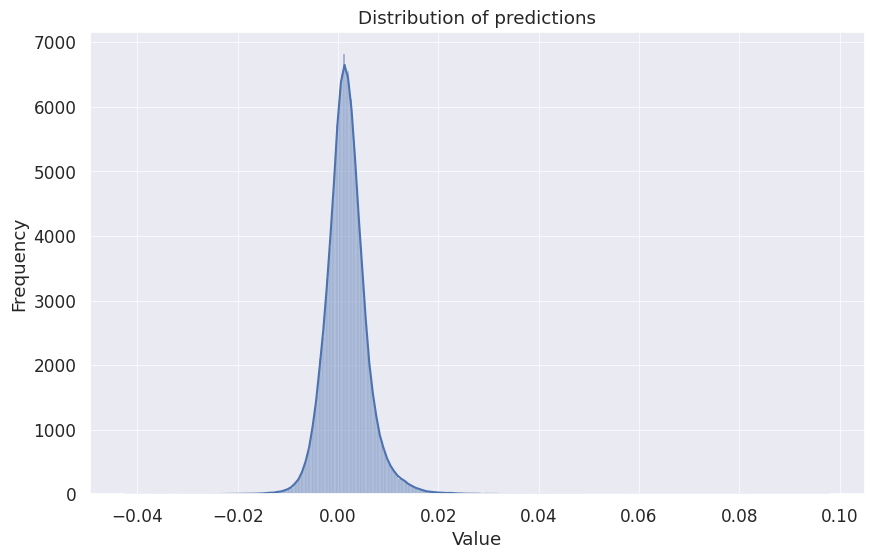

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['prediction'], bins=500, kde=True)
plt.title('Distribution of predictions')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [34]:
data.loc[idx['AAPL', :], :].droplevel('symbol', axis=0)

,prediction,close,high,low,open,volume
date,,,,,,
2024-05-21 00:00:00+00:00,-0.001800,190.260544,192.820007,190.270004,192.270004,34648500.0
2024-05-22 00:00:00+00:00,-0.000313,186.254013,191.000000,186.630005,190.979996,51005900.0
2024-05-23 00:00:00+00:00,0.002704,189.343628,190.580002,188.039993,188.820007,36294600.0
2024-05-24 00:00:00+00:00,0.001277,189.353592,193.000000,189.100006,191.509995,52280100.0
2024-05-28 00:00:00+00:00,0.001097,189.652588,192.250000,189.509995,189.610001,53068000.0
...,...,...,...,...,...,...
2025-03-19 00:00:00+00:00,0.001966,214.100006,217.490005,212.220001,213.990005,48862900.0
2025-03-20 00:00:00+00:00,0.003811,218.270004,218.839996,211.279999,211.559998,94127800.0
2025-03-21 00:00:00+00:00,0.004156,220.729996,221.479996,218.580002,221.000000,44299500.0


### Run Strategy Backtest

### Plot result

In [35]:
#cerebro.plot()  # plot the results
#figure = cerebro.plot(style='candlebars')[0][0]
#figure.savefig(f'backtrader.png')

In [36]:
#  requires at least 25 long candidates AND at least 25 short candidates to be identified before it will take any new long or short positions
N_POSITIONS = 25
MIN_POSITIONS = 10


In [37]:

#cerebro = bt.Cerebro()  # create a "Cerebro" instance


# Add the strategy
cerebro.addstrategy(MLStrategy, n_positions=N_POSITIONS, min_positions=MIN_POSITIONS,
                    verbose=True, log_file='bt_log.csv')


# Configure broker, slippage, commission etc.
#cash = 10000
#cerebro.broker.setcash(cash)
# cerebro.broker.set_cash(100000.0)
# cerebro.broker.setcommission(commission=0.001)

# --- Add QuantStats compatible Analyzer ---
# Instead of PyFolio, use TimeReturn to get returns data
cerebro.addanalyzer(bt.analyzers.TimeReturn, _name='time_return')

# Optional: Add other analyzers if you need more details later
# cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trade_analyzer')
# cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe_ratio', timeframe=bt.TimeFrame.Days)
# cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

# --- Run the Backtest ---
print("Running Backtest...")
start = time()
results = cerebro.run()
ending_value = cerebro.broker.getvalue()
duration = time() - start

print(f'Final Portfolio Value: {ending_value:,.2f}')
print(f'Duration: {format_time(duration)}')



Running Backtest...
Final Portfolio Value: 143,222.62
Duration: 00:00:41


In [38]:
# --- Analysis using QuantStats ---

# 1. Extract Returns from the TimeReturn Analyzer
#    It returns a dictionary {datetime: return}
returns_dict = results[0].analyzers.getbyname('time_return').get_analysis()
# Convert to a pandas Series, ensure index is DatetimeIndex
returns_ser = pd.Series(returns_dict)
returns_ser.index = pd.to_datetime(returns_ser.index) # Ensure index is DatetimeIndex
#returns_ser.index = pd.to_datetime(returns_ser.index).tz_localize('UTC')
#benchmark = web.DataReader('SP500', 'fred', '2014', '2025').squeeze()
#benchmark = benchmark.pct_change()#.tz_localize('UTC')

In [39]:
results[0]

In [40]:
returns_ser.head(10)

2024-05-21    0.000000
2024-05-22   -0.001479
2024-05-23   -0.014337
2024-05-24   -0.005213
2024-05-28   -0.006258
2024-05-29   -0.003060
2024-05-30    0.038061
2024-05-31    0.018450
2024-06-03    0.010849
2024-06-04    0.008362
dtype: float64

In [44]:
# Download S&P 500 index data (ticker: ^GSPC)
benchmark = yf.download('^GSPC', start=dates_tmp.min().strftime('%Y-%m-%d'), end=END,auto_adjust=False)['Adj Close'].squeeze()
benchmark = benchmark.pct_change()#.tz_localize('UTC')

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


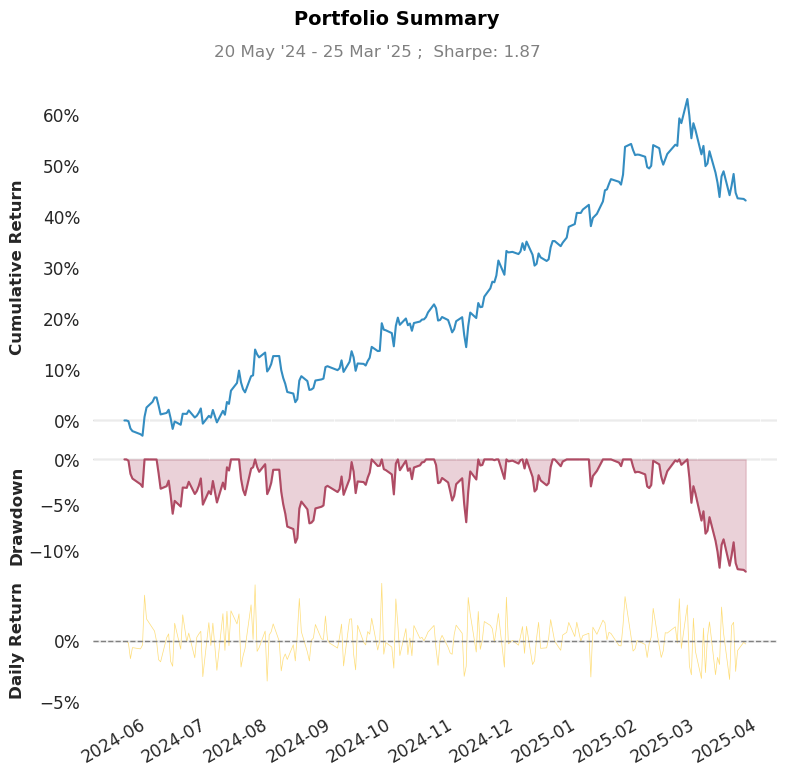

ValueError: cannot set a frame with no defined index and a scalar

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


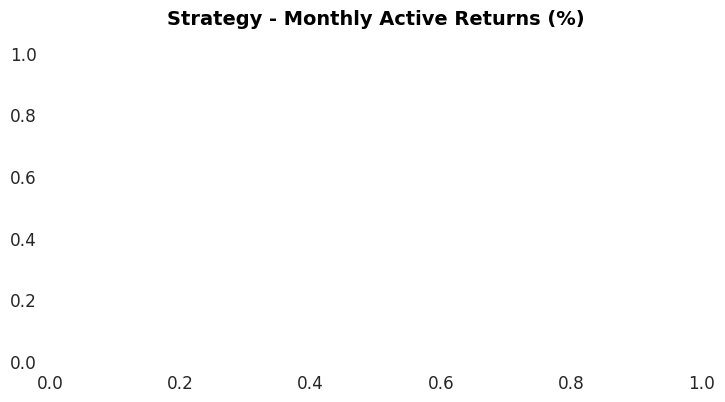

In [42]:
# Quantstats plots
#qs.plots.returns(returns_ser, benchmark)
qs.reports.plots(returns_ser, benchmark)
#qs.reports.html(returns_ser, benchmark=benchmark, output='strategy_report.html')

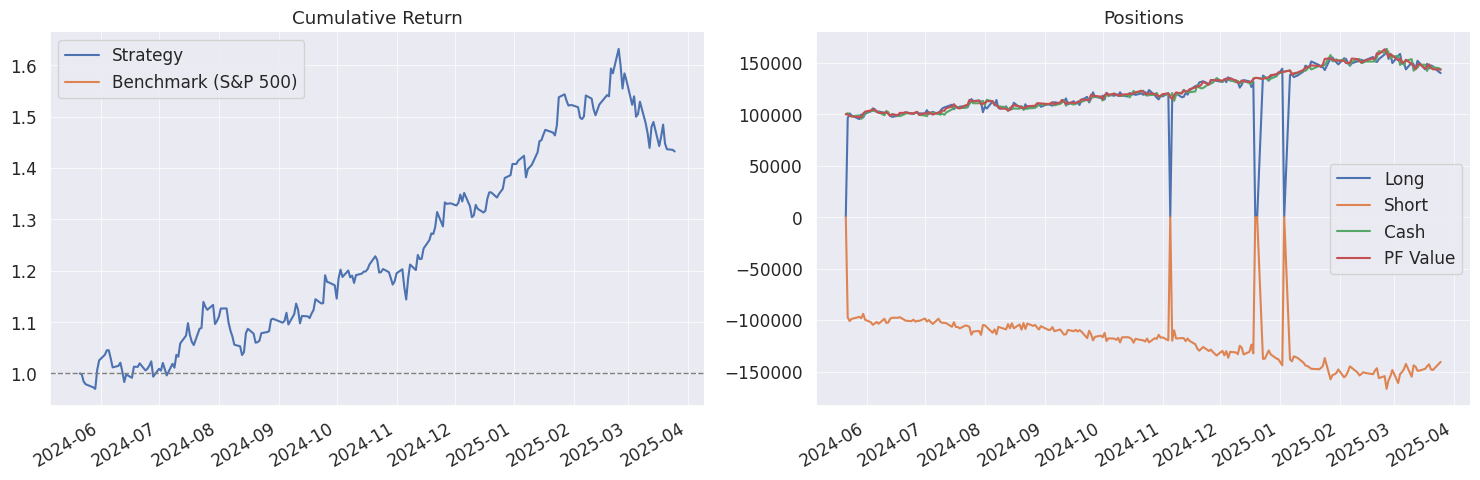

In [43]:
import matplotlib.dates as mdates
# First plot with returns
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))

# Plot cumulative returns in first subplot
df = pd.DataFrame({'Strategy': returns_ser, 'Benchmark (S&P 500)': benchmark})
#df.add(1).cumprod().sub(1).plot(ax=axes[0], title='Cumulative Return')
df.add(1).cumprod().plot(ax=axes[0], title='Cumulative Return')

# Plot positions in second subplot
strategy = results[0]  # Get your strategy instance
strategy.long_values.plot(label='Long', ax=axes[1], title='Positions')
strategy.short_values.plot(ax=axes[1], label='Short')
strategy.cash_values.plot(ax=axes[1], label='Cash')
# If you want total portfolio value instead of just cash:
portfolio_value = strategy.long_values + strategy.short_values + strategy.cash_values
portfolio_value.plot(ax=axes[1], label='PF Value')

axes[1].legend()
fig.autofmt_xdate() # diagonalize the axes
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=1)
sns.despine()
fig.tight_layout()
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2019-03-22   2019-03-22
End Period                 2025-03-26   2025-03-26
Risk-Free Rate             0.0%         0.0%
Time in Market             100.0%       100.0%

Cumulative Return          104.13%      4,349.65%
CAGR﹪                     8.53%        54.58%

Sharpe                     0.69         1.16
Prob. Sharpe Ratio         95.23%       99.81%
Smart Sharpe               0.48         0.81
Sortino                    0.96         1.8
Smart Sortino              0.67         1.26
Sortino/√2                 0.68         1.28
Smart Sortino/√2           0.47         0.89
Omega                      1.25         1.25

Max Drawdown               -33.92%      -40.61%
Longest DD Days            745          198
Volatility (ann.)          20.18%       86.41%
R^2                        0.02         0.02
Information Ratio          0.06         0.06
Calmar           

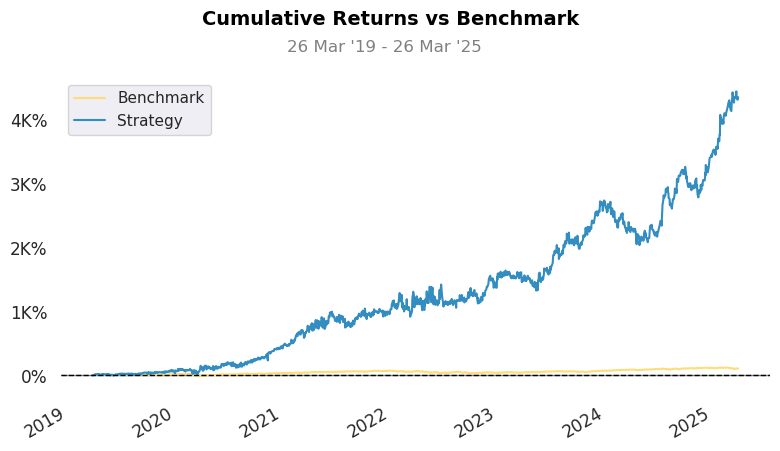

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


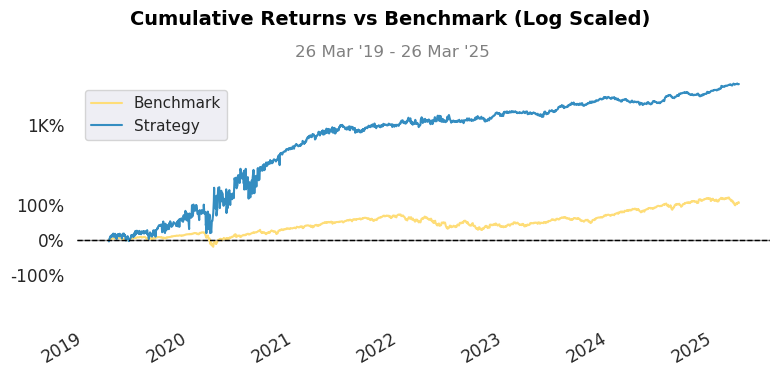

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


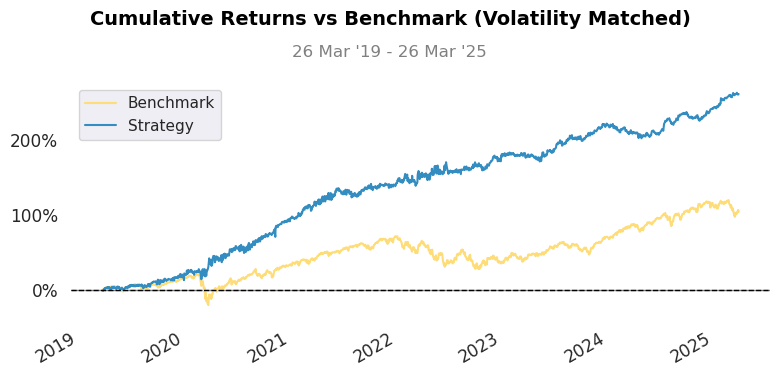

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


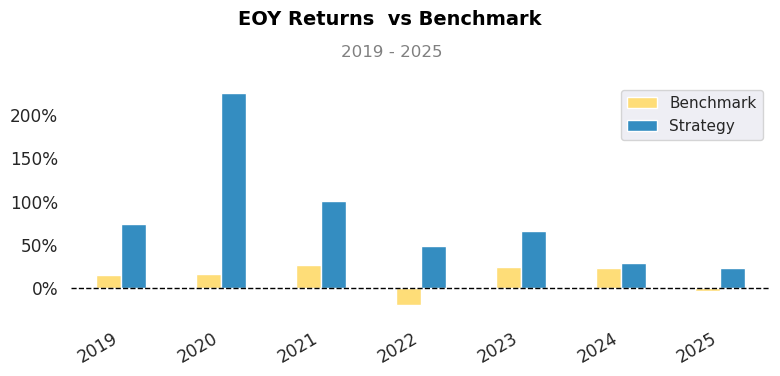

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


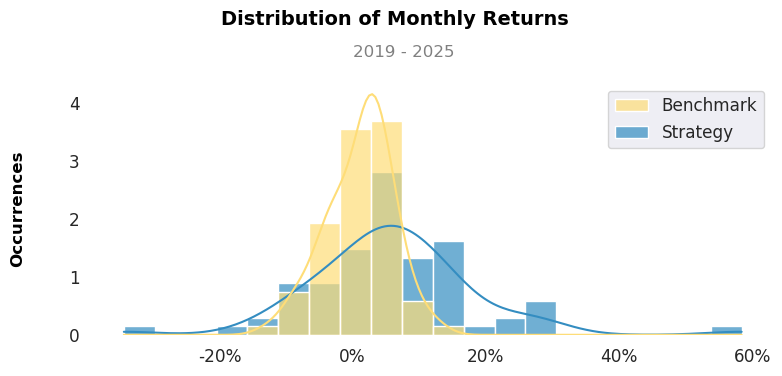

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


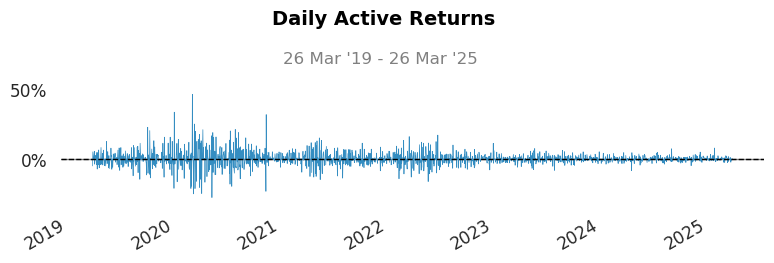

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


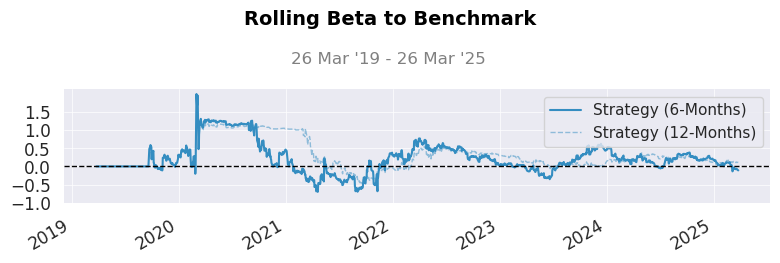

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


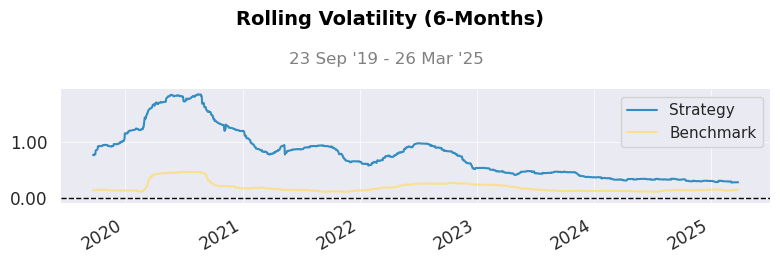

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


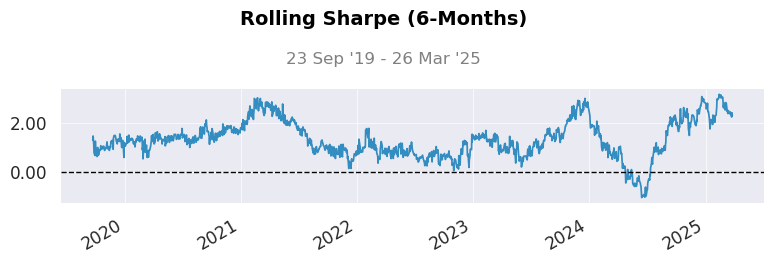

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


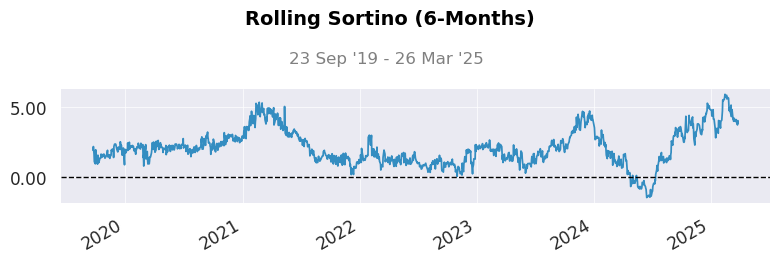

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


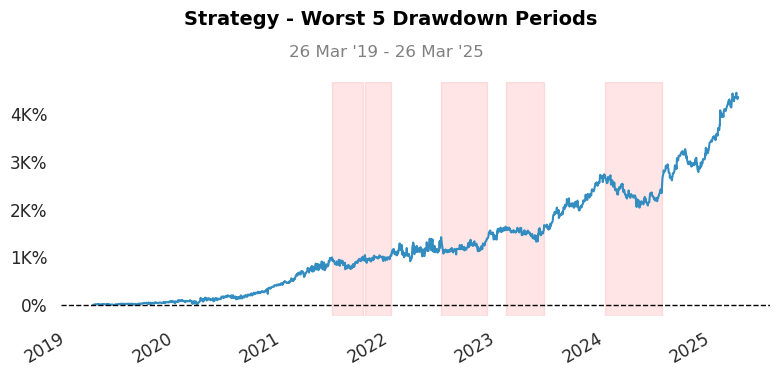

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


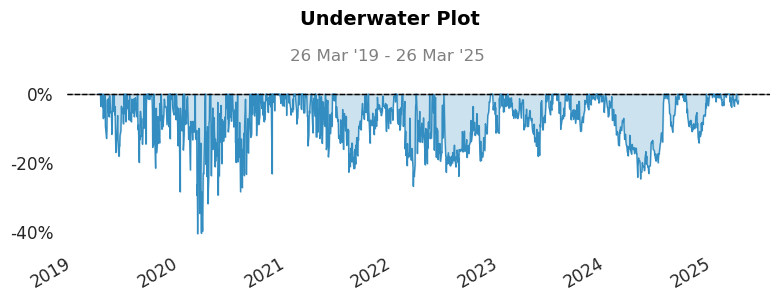

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


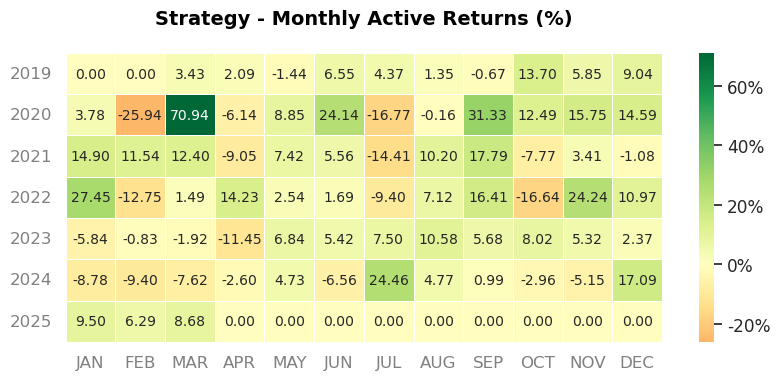

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


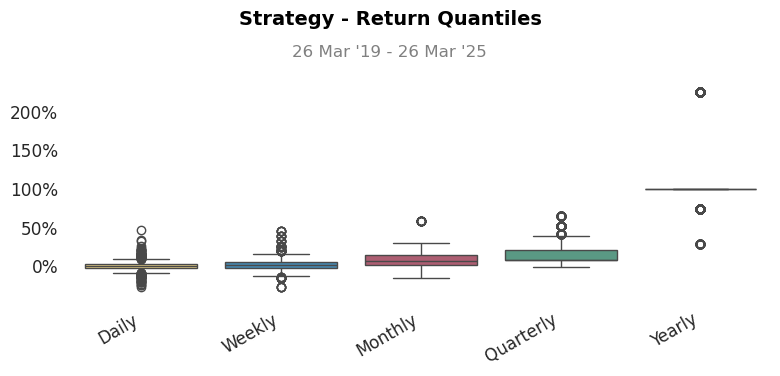

In [ ]:

# Enable matplotlib integration
qs.extend_pandas()

# Create a full HTML report
qs.reports.html(returns_ser, 
                benchmark=benchmark.dropna(), 
                output='quantstats_report.html',
                title='Trading Strategy Performance')

# For a snapshot of metrics in your notebook
qs.reports.metrics(returns_ser, benchmark=benchmark.dropna(), mode='full')

# For just the plots
qs.reports.plots(returns_ser, benchmark=benchmark.dropna(), mode='full')